# Zadanie 20  Kompletny projekt ML

## Przeprowadź pełny projekt ML: od EDA po ewaluację.
### Dataset: California Housing
### Wymagania:
- EDA z wizualizacjami
- Feature engineering (nowe cechy)
- Porównanie 3+ modeli regresji
- Cross-validation
- Feature importance
- Raport końcowy z wnioskami
- Aspekt Green IT: porównanie efektywności

### Oczekiwany rezultat:
- Notebook z pełnym projektem
- Wizualizacje EDA
- Tabela porównawcza modeli
- Wnioski i rekomendacje

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing # Wbudowane datasety
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn import linear_model # Modele liniowe
from sklearn import ensemble # Random Forest, Gradient Boosting
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline


data = fetch_california_housing(as_frame=True)

### EDA

In [3]:
dane = data.frame
dane.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
dane.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: MedInc, dtype: float64

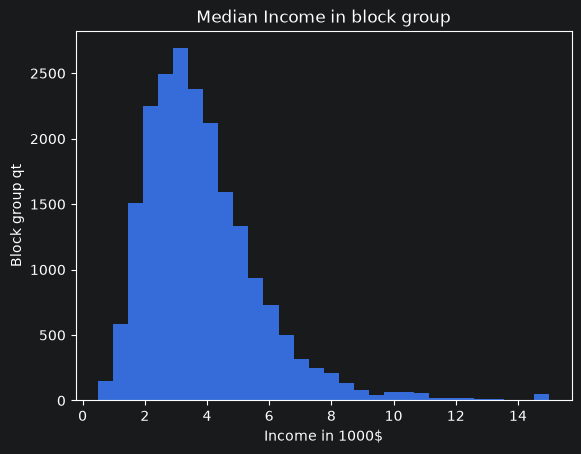

In [5]:
fig, ax = plt.subplots()
plt.title('Median Income in block group')
plt.ylabel('Block group qt')
plt.xlabel('Income in 1000$')
plt.hist(dane['MedInc'], bins=30)

dane['MedInc'].describe()

#Mediana przychodu per grupa (600-3000os.).
# Prawoskośny wykres, ze średnią w 3.8. Większość w przedziale 2.56-4.74, są outliery, min -- 0.4999, max -- 15.000

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: HouseAge, dtype: float64

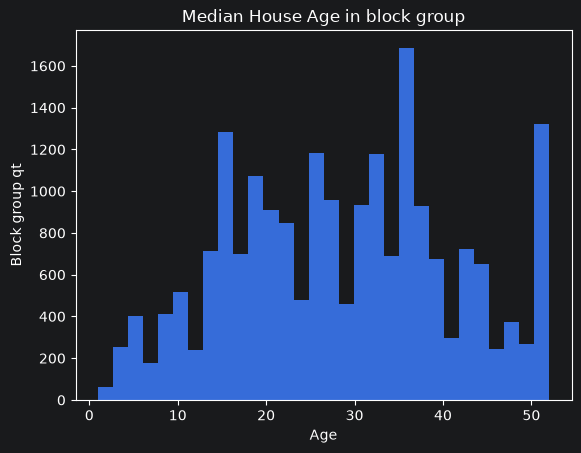

In [6]:
fig, ax = plt.subplots()
plt.title('Median House Age in block group')
plt.ylabel('Block group qt')
plt.xlabel('Age')

plt.hist(dane['HouseAge'], bins=30)

dane['HouseAge'].describe()

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: AveRooms, dtype: float64

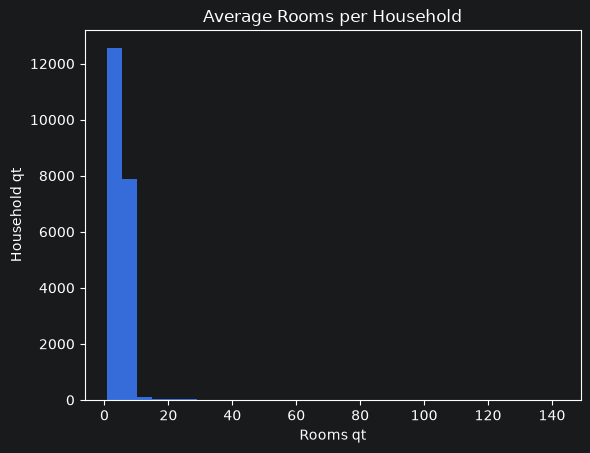

In [7]:
fig, ax = plt.subplots()
plt.title('Average Rooms per Household')
plt.ylabel('Household qt')
plt.xlabel('Rooms qt')
plt.hist(dane['AveRooms'], bins=30)

dane['AveRooms'].describe()

#Wyraźny outlier z 142 liczbą pokoi per household. prawdopodobnie - vacation resort.

count    20640.000000
mean         1.096675
std          0.473911
min          0.333333
25%          1.006079
50%          1.048780
75%          1.099526
max         34.066667
Name: AveBedrms, dtype: float64

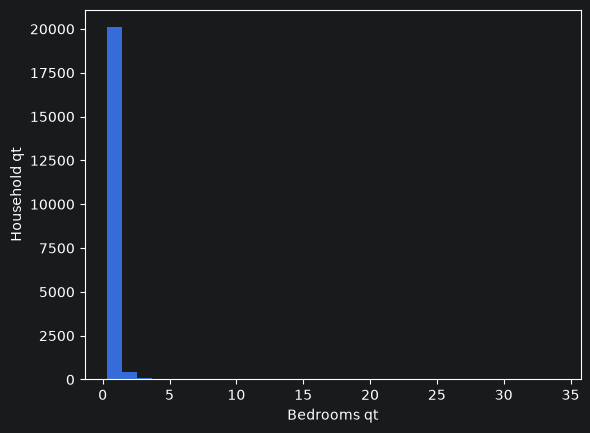

In [8]:
fig, ax = plt.subplots()
plt.xlabel('Average Bedrooms per Household')
plt.ylabel('Household qt')
plt.xlabel('Bedrooms qt')
plt.hist(dane['AveBedrms'], bins=30)

dane['AveBedrms'].describe()

#podobny wykres do średniej pokoji per household. Prawdodopobnie do wykluczenia przez dużą korelację. większość mieści się około 1, outlier ma 34

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: Population, dtype: float64

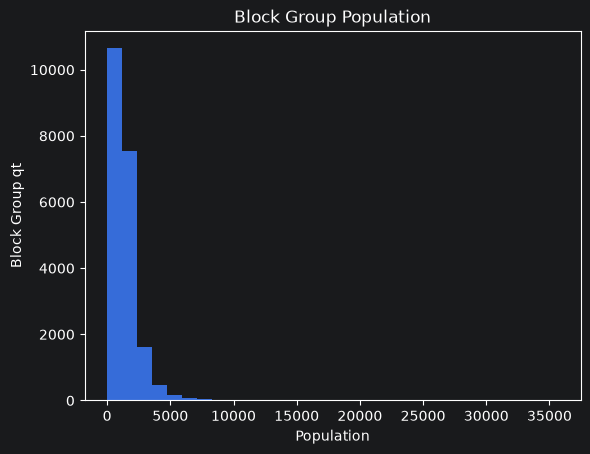

In [9]:
fig, ax = plt.subplots()
plt.title('Block Group Population')
plt.ylabel('Block Group qt')
plt.xlabel('Population')
plt.hist(dane['Population'], bins=30)

dane['Population'].describe()

#też posiada duży outlier

count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

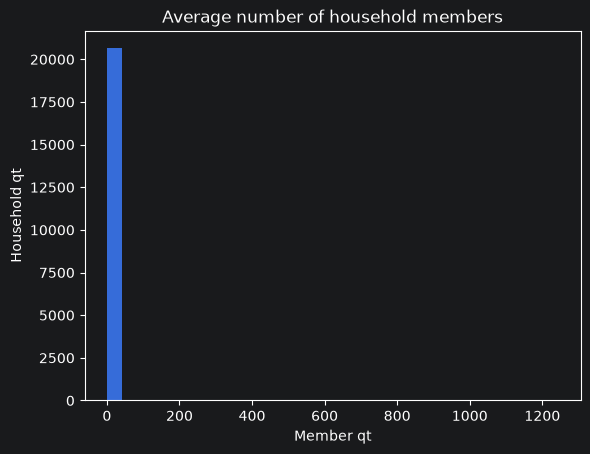

In [10]:
fig, ax = plt.subplots()
plt.title('Average number of household members')
plt.ylabel('Household qt')
plt.xlabel('Member qt')
plt.hist(dane['AveOccup'], bins=30)
dane['AveOccup'].describe()

(array([  16.,  111.,  750., 1014., 1353., 1245., 1295., 1371., 1433.,
        1501., 1350.,  920., 1089.,  958.,  752.,  730.,  619.,  420.,
         367.,  418.,  454.,  311.,  232.,  209.,  173.,  145.,  161.,
          98.,   87., 1058.]),
 array([0.14999   , 0.31165733, 0.47332467, 0.634992  , 0.79665933,
        0.95832667, 1.119994  , 1.28166133, 1.44332867, 1.604996  ,
        1.76666333, 1.92833067, 2.089998  , 2.25166533, 2.41333267,
        2.575     , 2.73666733, 2.89833467, 3.060002  , 3.22166933,
        3.38333667, 3.545004  , 3.70667133, 3.86833867, 4.030006  ,
        4.19167333, 4.35334067, 4.515008  , 4.67667533, 4.83834267,
        5.00001   ]),
 <BarContainer object of 30 artists>)

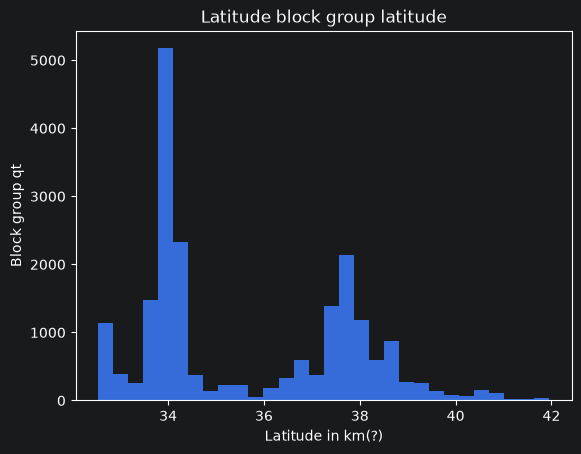

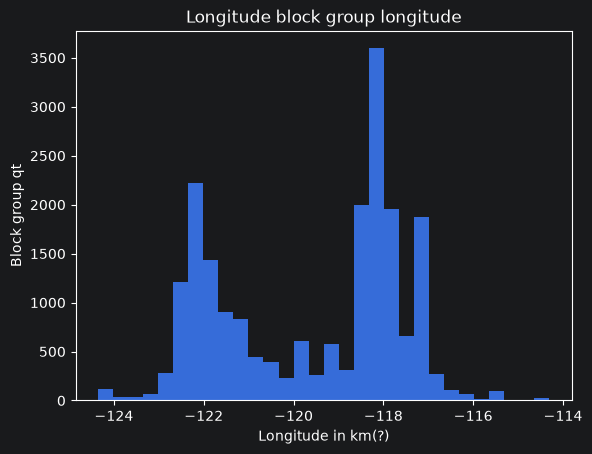

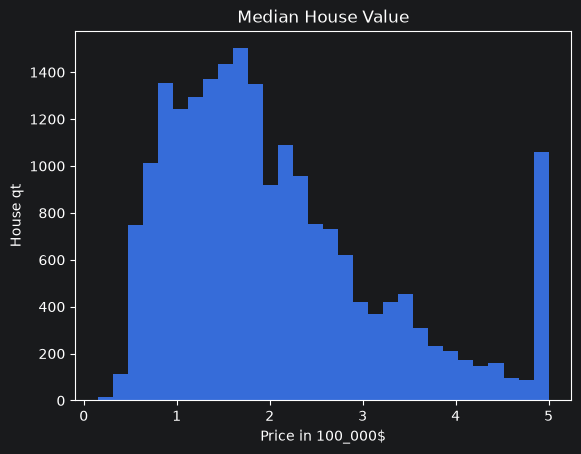

In [11]:
fig, ax = plt.subplots()
plt.title('Latitude block group latitude')
plt.ylabel('Block group qt')
plt.xlabel('Latitude in km(?)')
plt.hist(dane['Latitude'], bins=30)

fig, ax = plt.subplots()
plt.title('Longitude block group longitude')
plt.ylabel('Block group qt')
plt.xlabel('Longitude in km(?)')
plt.hist(dane['Longitude'], bins=30)

fig, ax = plt.subplots()
plt.title('Median House Value')
plt.ylabel('House qt')
plt.xlabel('Price in 100_000$')
plt.hist(dane['MedHouseVal'], bins=30)

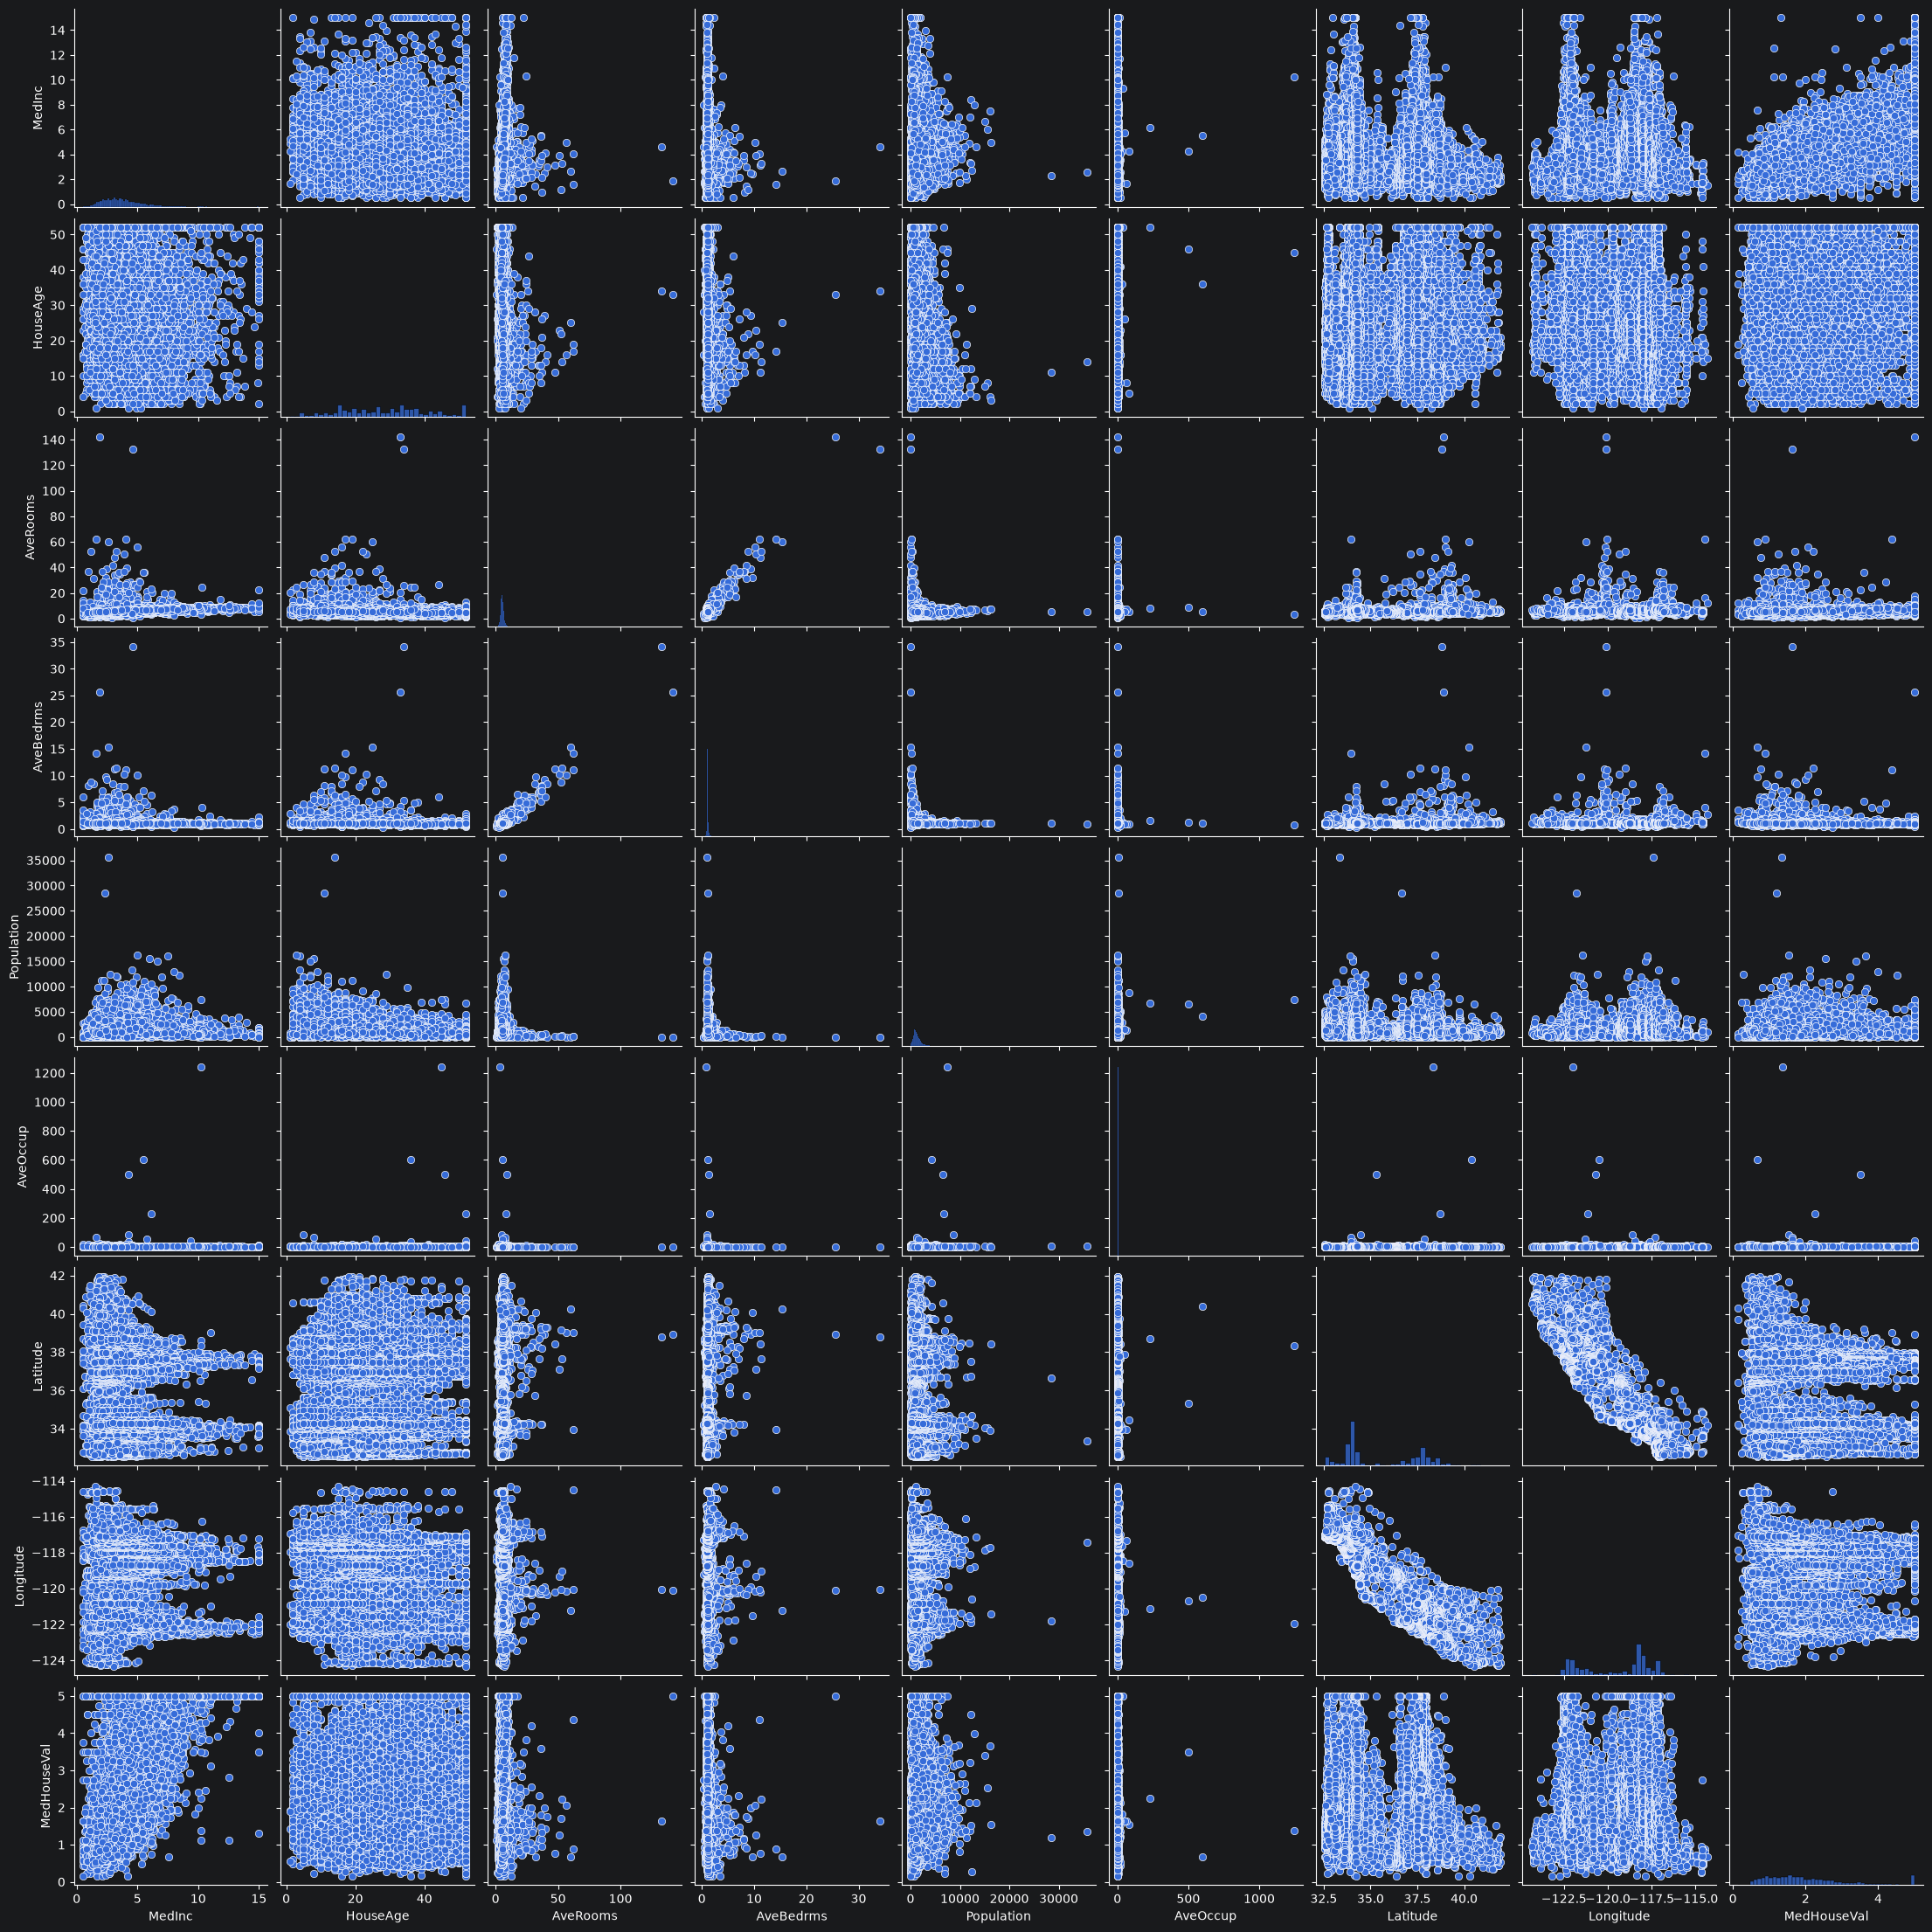

In [12]:
sns.pairplot(dane[['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude','MedHouseVal']])
plt.show()

1. Widać, że Averooms, AveBedrms, Population oraz AveOccup potrzebują pracy, bo outliery mocno spłaszczają w porównaniu do targetu MedHouseVal
2. Dużo domów mają cenę równo 5.
3. Jest korelacja z Medinc -> zazwyczaj, im większy przychód mediany, tym większa cena mieszkania.
4. Longitude i Latitude to szerokość i długośc geograficzna -> gdy utworzyć tabelę z nimi (x,y), to może znajdę zależność ceny od umiejscowienia
5. Averooms oraz AveBedrms są między sobą skorelowane, więc prawdopodobnie wybiorę w przyszłości jedną kolumnę

Text(0.5, 1.0, 'Cena domu w zależności od miejsca na mapie')

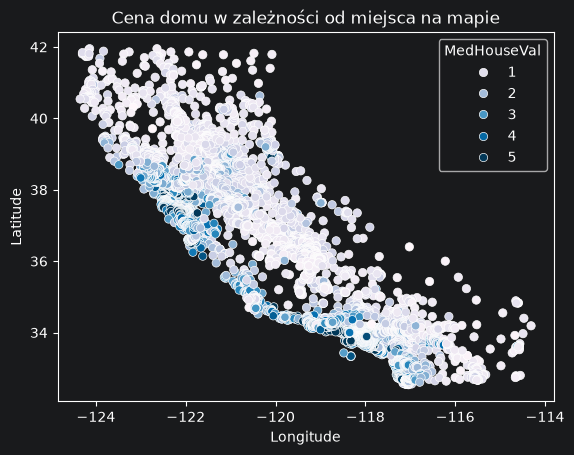

In [13]:
sns.scatterplot(dane, y='Latitude', x='Longitude', hue='MedHouseVal', palette='PuBu')
plt.title('Cena domu w zależności od miejsca na mapie')

Skoro, to jest kalifornia, widać, że ceny na mieszkania największe są około oceanu. Nie wiedziałem w jaki sposób przekazać tą informację do modelu liniowego, ale chat podpowiedział, że przecież można znaleźć punkt odniesienia -- wybrać kilka miast i policzyć jak daleko znajduje się od niego każdy dom.

Wygooglowałem, że dla wyliczenia długości pomiędzy miastami korzysta się z formuły Haversine

R = 6371 (radius Ziemi)\
a = sin²(ΔLatitude/2) + cos(Latitude₁) · cos(Latitude₂) · sin²(ΔLongitude/2)\
dystans = 2 * R * arcsin(sqrt(a))\

Wybieram miasta z dwoma największymy zbiorami wysokich cen to są San Francisko z [37.77 latitude  -122.26 longitude] oraz  Los Angeles z [34.03 latitude 118.15 longitude] . Dodam jeszcze jeden punk, gdzie więcej drogich mieszkań - jeziero Tahoe [39.3 , -120.2]

In [14]:
#tutaj myślę, że warto jeszcze dodać

dane['Longitude_radian'] = np.radians(dane['Longitude'])
dane['Latitude_radian'] = np.radians(dane['Latitude'])

SF_latitude_radians = np.radians(37.77)
SF_longitude_radians = np.radians(-122.26)
LA_latitude_radians = np.radians(34.03)
LA_longitude_radians = np.radians(-118.15)
JT_latitude_radians = np.radians(39.3)
JT_longitude_radians = np.radians(-120.2)


dane['Dystans_to_SF'] = (2*6371*
                         np.asin(
                             np.sqrt(
                                 np.sin((dane['Latitude_radian']-SF_latitude_radians)/2)**2+
                                 np.cos(dane['Latitude_radian'])*
                                 np.cos(SF_latitude_radians)*
                                 np.sin((dane['Longitude_radian']-SF_longitude_radians)/2)**2
                             )))



dane['Dystans_to_LA'] = (2*6371*
                         np.asin(
                             np.sqrt(
                                 np.sin((dane['Latitude_radian']-LA_latitude_radians)/2)**2+
                                 np.cos(dane['Latitude_radian'])*
                                 np.cos(LA_latitude_radians)*
                                 np.sin((dane['Longitude_radian']-LA_longitude_radians)/2)**2
                             )))

dane['Dystans_to_JT'] = (2*6371*
                         np.asin(
                             np.sqrt(
                                 np.sin((dane['Latitude_radian']-JT_latitude_radians)/2)**2+
                                 np.cos(dane['Latitude_radian'])*
                                 np.cos(JT_latitude_radians)*
                                 np.sin((dane['Longitude_radian']-JT_longitude_radians)/2)**2
                             )))


print('Domy bliskie do San Francisko:\n')
print(dane[['Dystans_to_SF','Dystans_to_LA']][((dane['Latitude']>37)&(dane['Latitude']<38))&((dane['Longitude']<-122)&(dane['Longitude']>-123))].head(),end='\n\n')

print('Domy bliskie do Los Angeles:\n')
print(dane[['Dystans_to_SF','Dystans_to_LA']][((dane['Latitude']>34)&(dane['Latitude']<34.5))&((dane['Longitude']>-118.5)&(dane['Longitude']<-118))].head())



Domy bliskie do San Francisko:

   Dystans_to_SF  Dystans_to_LA
0      12.512038     563.901547
1      10.606472     561.659765
2       9.067447     562.009395
3       8.938867     562.598898
4       8.938867     562.598898

Domy bliskie do Los Angeles:

      Dystans_to_SF  Dystans_to_LA
3370     529.254238      28.881187
3371     529.479477      28.234687
3372     528.872482      28.636755
3373     528.266319      29.062411
3374     528.266319      29.062411


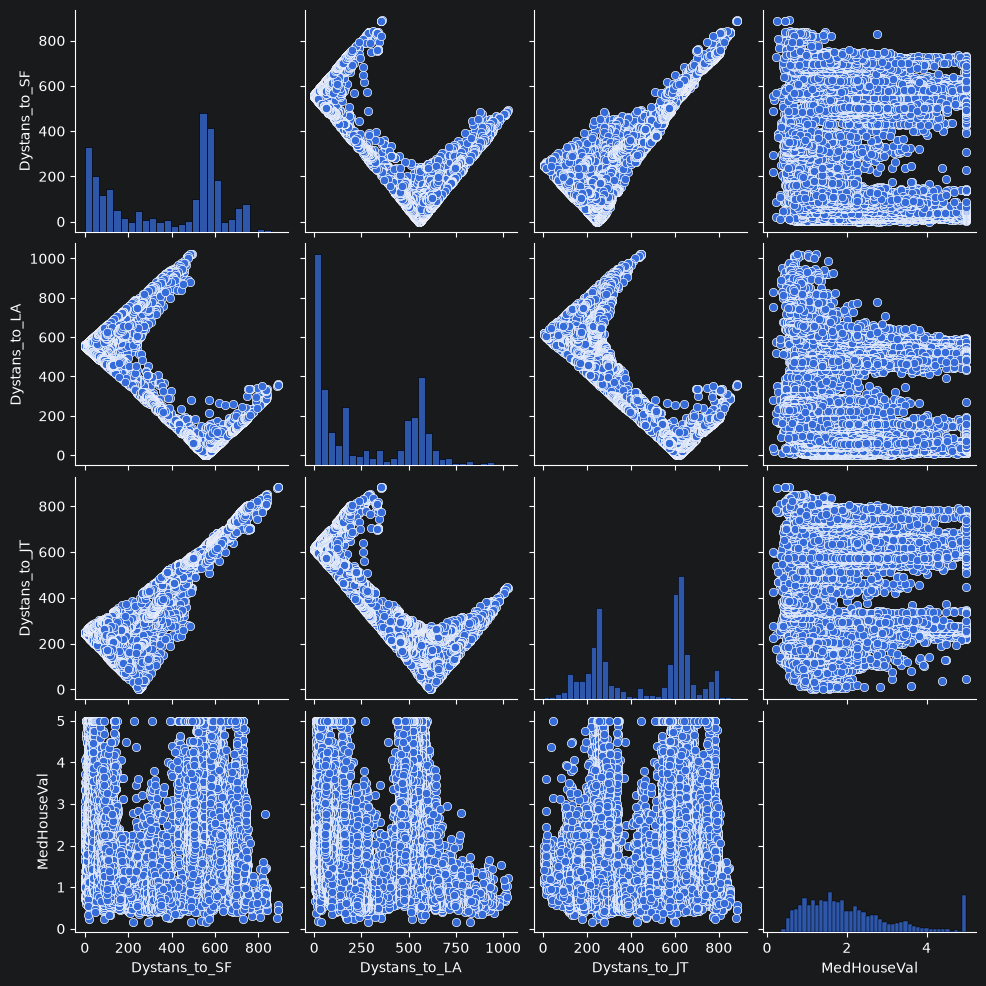

In [15]:
sns.pairplot(dane[['Dystans_to_SF','Dystans_to_LA', 'Dystans_to_JT', 'MedHouseVal']])

Wracając teraz do

In [16]:
#Szukając w jaki sposób mogę pracować z outlierami, to widziałem, że można określać Outliery za pomocą wskaźnika IQR (wszystko co jest poniżej 25 percentyl*1.5 IQR lub powyżej 75 percentyla * 1.5 IQR jest outlierem, ale mi się nie spodobało - za ciasno jest

#IQR = dystans między 25 oraz 75 percentylem

# IQR = averooms_logged.quantile(0.75)-averooms_logged.quantile(0.25)
#
# lower_iqr = averooms_logged.quantile(0.25)-1.5*IQR
# higher_iqr = averooms_logged.quantile(0.75)+1.5*IQR
#
# print(lower_iqr,higher_iqr)
#
# print(averooms_logged[averooms_logged<lower_iqr].count())
# print(averooms_logged[averooms_logged>higher_iqr].count())

Wracając teraz do wszystkich prawoskośnych wykresów: MedInc, Averooms, AveBedrms, Population oraz AveOccup. Najpierw chcę je spłaszczyć za pomocą logarytmu, a dla walki z outlierami, wszystko powyżej 99 percentyla dorównam do 99, a wszystko poniżej 1 dorównam z 1. Czat sugeruje dodać dla wszystkich ograniczonych splitem wartości kolumnę is_outlier 0/1. Brzmi legit

Doczytałem się, że takie rzeczy jak wyliczenia percentyli, mean oraz std na pełnym zbiorze prowadzą do Data Leakage, więc dzielę na test/train

In [17]:
dane['MedInc_log'] = np.log(dane['MedInc'])
dane['AveRooms_log'] = np.log(dane['AveRooms'])
dane['AveBedrms_log'] = np.log(dane['AveBedrms'])
dane['Population_log'] = np.log(dane['Population'])
dane['AveOccup_log'] = np.log(dane['AveOccup'])

(array([2.000e+00, 5.000e+00, 1.110e+02, 9.400e+02, 3.894e+03, 8.817e+03,
        5.072e+03, 1.499e+03, 2.220e+02, 2.800e+01, 1.500e+01, 1.500e+01,
        6.000e+00, 5.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([-0.36772478, -0.11794891,  0.13182695,  0.38160282,  0.63137869,
         0.88115455,  1.13093042,  1.38070629,  1.63048215,  1.88025802,
         2.13003389,  2.37980975,  2.62958562,  2.87936149,  3.12913736,
         3.37891322,  3.62868909,  3.87846496,  4.12824082,  4.37801669,
         4.62779256,  4.87756842,  5.12734429,  5.37712016,  5.62689602,
         5.87667189,  6.12644776,  6.37622362,  6.62599949,  6.87577536,
         7.12555122]),
 <BarContainer object of 30 artists>)

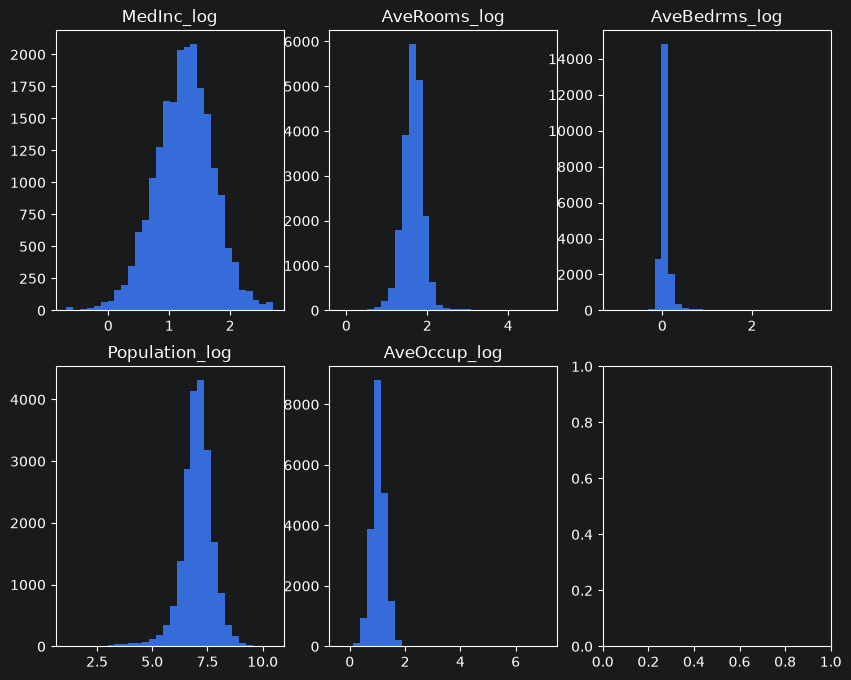

In [18]:
fig, ax = plt.subplots(2,3, figsize=(10,8))
ax[0,0].set_title('MedInc_log')
ax[0,0].hist(dane['MedInc_log'], bins=30)
ax[0,1].set_title('AveRooms_log')
ax[0,1].hist(dane['AveRooms_log'], bins=30)
ax[0,2].set_title('AveBedrms_log')
ax[0,2].hist(dane['AveBedrms_log'], bins=30)
ax[1,0].set_title('Population_log')
ax[1,0].hist(dane['Population_log'], bins=30)
ax[1,1].set_title('AveOccup_log')
ax[1,1].hist(dane['AveOccup_log'], bins=30)

Zastosuję capping na danych treningowych dla każdego z wykresów

In [19]:
X= dane.drop('MedHouseVal',axis=1)

y= dane['MedHouseVal']

X_train, X_test,y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)



In [20]:
#Mogę wyliczyć percyntel dla danych testowych (żeby nie było Data Leakage), a później zrobić clip na danych treningowy i testowych

lower_cap_medinc = X_train['MedInc_log'].quantile(0.01)
higher_cap_medinc = X_train['MedInc_log'].quantile(0.99)
dane['MedInc_log_capped'] = dane['MedInc_log'].clip(lower= lower_cap_medinc, upper= higher_cap_medinc)

lower_cap_averooms = X_train['AveRooms_log'].quantile(0.01)
higher_cap_averooms = X_train['AveRooms_log'].quantile(0.99)
dane['AveRooms_log_capped'] = dane['AveRooms_log'].clip(lower= lower_cap_averooms, upper= higher_cap_averooms)

lower_cap_AveBedrms = X_train['AveBedrms_log'].quantile(0.01)
higher_cap_AveBedrms = X_train['AveBedrms_log'].quantile(0.99)
dane['AveBedrms_log_capped'] = dane['AveBedrms_log'].clip(lower= lower_cap_AveBedrms, upper= higher_cap_AveBedrms)

lower_cap_Population = X_train['Population_log'].quantile(0.01)
higher_cap_Population = X_train['Population_log'].quantile(0.99)
dane['Population_log_capped'] = dane['Population_log'].clip(lower= lower_cap_Population, upper= higher_cap_Population)

lower_cap_AveOccup = X_train['AveOccup_log'].quantile(0.01)
higher_cap_AveOccup = X_train['AveOccup_log'].quantile(0.99)
dane['AveOccup_log_capped'] = dane['AveOccup_log'].clip(lower= lower_cap_AveOccup, upper= higher_cap_AveOccup)


(array([ 313.,  127.,  170.,  212.,  322.,  396.,  446.,  544.,  703.,
         905., 1140., 1308., 1478., 1576., 1572., 1524., 1439., 1210.,
        1065.,  810.,  719.,  549.,  428.,  402.,  349.,  243.,  209.,
         124.,   80.,  277.]),
 array([0.43102742, 0.47293575, 0.51484409, 0.55675243, 0.59866076,
        0.6405691 , 0.68247743, 0.72438577, 0.7662941 , 0.80820244,
        0.85011078, 0.89201911, 0.93392745, 0.97583578, 1.01774412,
        1.05965245, 1.10156079, 1.14346913, 1.18537746, 1.2272858 ,
        1.26919413, 1.31110247, 1.3530108 , 1.39491914, 1.43682748,
        1.47873581, 1.52064415, 1.56255248, 1.60446082, 1.64636915,
        1.68827749]),
 <BarContainer object of 30 artists>)

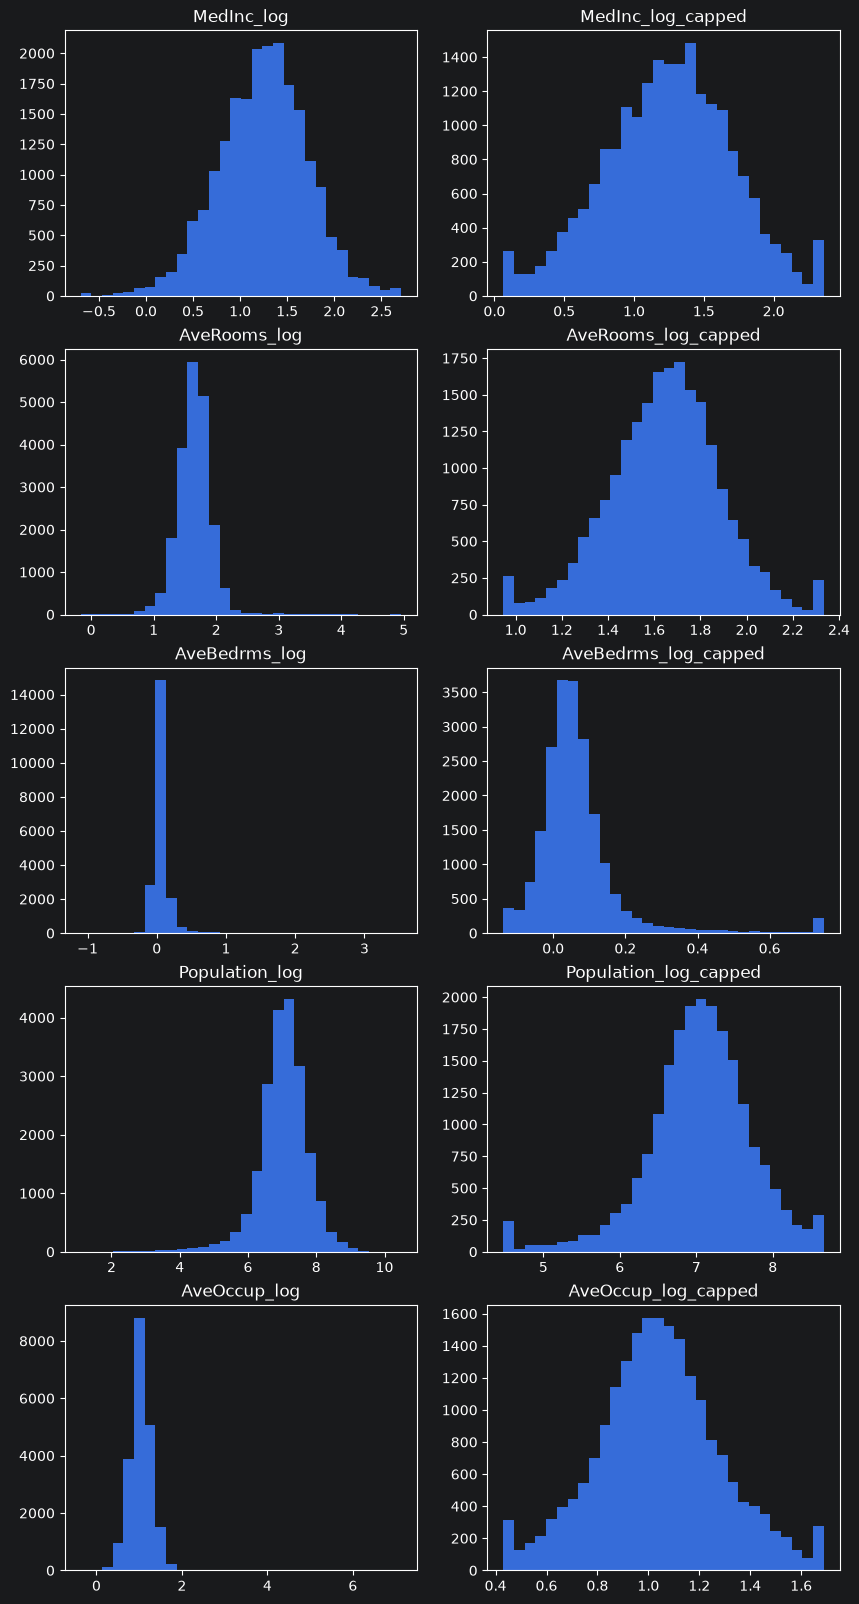

In [21]:
fig, ax = plt.subplots(5,2, figsize=(10,20))
ax[0,0].set_title('MedInc_log')
ax[0,0].hist(dane['MedInc_log'], bins=30)
ax[0,1].set_title('MedInc_log_capped')
ax[0,1].hist(dane['MedInc_log_capped'], bins=30)

ax[1,0].set_title('AveRooms_log')
ax[1,0].hist(dane['AveRooms_log'], bins=30)
ax[1,1].set_title('AveRooms_log_capped')
ax[1,1].hist(dane['AveRooms_log_capped'], bins=30)

ax[2,0].set_title('AveBedrms_log')
ax[2,0].hist(dane['AveBedrms_log'], bins=30)
ax[2,1].set_title('AveBedrms_log_capped')
ax[2,1].hist(dane['AveBedrms_log_capped'], bins=30)

ax[3,0].set_title('Population_log')
ax[3,0].hist(dane['Population_log'], bins=30)
ax[3,1].set_title('Population_log_capped')
ax[3,1].hist(dane['Population_log_capped'], bins=30)

ax[4,0].set_title('AveOccup_log')
ax[4,0].hist(dane['AveOccup_log'], bins=30)
ax[4,1].set_title('AveOccup_log_capped')
ax[4,1].hist(dane['AveOccup_log_capped'], bins=30)


Nowe wykresy wyglądają znacznie lepiej. Teraz dla każdego wykresu chcę dodać wartość Is_Outlier z 0/1

In [22]:
dane['MedInc_is_outlier'] = (dane['MedInc_log']>higher_cap_medinc) | (dane['MedInc_log']<lower_cap_medinc)
dane['AveRooms_is_outlier'] = (dane['AveRooms_log']>higher_cap_averooms) | (dane['AveRooms_log']<lower_cap_averooms)
dane['AveBedrms_is_outlier'] = (dane['AveBedrms_log']>higher_cap_AveBedrms) | (dane['AveBedrms_log']<lower_cap_AveBedrms)
dane['Population_is_outlier'] = (dane['Population_log']>higher_cap_Population) | (dane['Population_log']<lower_cap_Population)
dane['AveOccup_is_outlier'] = (dane['AveOccup_log']>higher_cap_AveOccup) | (dane['AveOccup_log']<lower_cap_AveOccup)

In [23]:
print('Przykładowe wartości dla outlierów w MedInc')

print(dane[['MedInc','MedInc_log', 'MedInc_log_capped', 'MedInc_is_outlier']][dane['MedInc_is_outlier'] == True].sort_values('MedInc').head())
print(dane[['MedInc','MedInc_log', 'MedInc_log_capped', 'MedInc_is_outlier']][dane['MedInc_is_outlier'] == True].sort_values('MedInc',ascending=False).head())



Przykładowe wartości dla outlierów w MedInc
       MedInc  MedInc_log  MedInc_log_capped  MedInc_is_outlier
20091  0.4999   -0.693347           0.064755               True
6688   0.4999   -0.693347           0.064755               True
7125   0.4999   -0.693347           0.064755               True
6343   0.4999   -0.693347           0.064755               True
13999  0.4999   -0.693347           0.064755               True
        MedInc  MedInc_log  MedInc_log_capped  MedInc_is_outlier
18504  15.0001    2.708057           2.358672               True
18501  15.0001    2.708057           2.358672               True
17858  15.0001    2.708057           2.358672               True
17170  15.0001    2.708057           2.358672               True
17166  15.0001    2.708057           2.358672               True


In [25]:
dane_po_EDA = dane[['MedInc_log_capped','HouseAge','AveRooms_log_capped','AveBedrms_log_capped','Population_log_capped','AveOccup_log_capped','Longitude', 'Latitude', 'Dystans_to_SF','Dystans_to_LA','Dystans_to_JT','MedInc_is_outlier','AveRooms_is_outlier','AveBedrms_is_outlier', 'Population_is_outlier', 'AveOccup_is_outlier','MedHouseVal']]

#Jeszcze raz rozdzielę dane, żeby w train i test pojawili się nowe kolumny

X= dane_po_EDA.drop('MedHouseVal',axis=1)

y= dane_po_EDA['MedHouseVal']

X_train, X_test,y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.describe())
print(y_train.describe())

       MedInc_log_capped      HouseAge  AveRooms_log_capped  \
count       16512.000000  16512.000000         16512.000000   
mean            1.247314     28.608285             1.645855   
std             0.460393     12.602499             0.245337   
min             0.064755      1.000000             0.947090   
25%             0.942621     18.000000             1.493366   
50%             1.265764     29.000000             1.655534   
75%             1.563012     37.000000             1.801881   
max             2.358672     52.000000             2.333932   

       AveBedrms_log_capped  Population_log_capped  AveOccup_log_capped  \
count          16512.000000           16512.000000         16512.000000   
mean               0.066668               7.030141             1.039714   
std                0.119812               0.696911             0.244830   
min               -0.137928               4.478580             0.431027   
25%                0.006487               6.670766       

<Axes: >

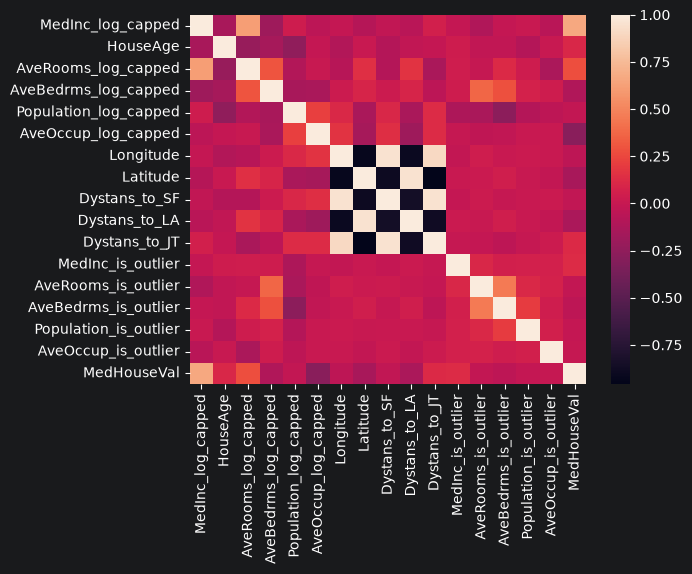

In [26]:
#Korelacje warto liczyć na danych treningowych

dane_treningowe = pd.concat([X_train,y_train],axis=1)

dane_do_heatmapy = (dane_treningowe)

sns.heatmap(dane_do_heatmapy.corr())

In [27]:
dane_do_heatmapy.corr()

,MedInc_log_capped,HouseAge,AveRooms_log_capped,AveBedrms_log_capped,Population_log_capped,AveOccup_log_capped,Longitude,Latitude,Dystans_to_SF,Dystans_to_LA,Dystans_to_JT,MedInc_is_outlier,AveRooms_is_outlier,AveBedrms_is_outlier,Population_is_outlier,AveOccup_is_outlier,MedHouseVal
MedInc_log_capped,1.000000,-0.146131,0.617111,-0.190930,0.033787,-0.054684,-0.017611,-0.082124,-0.028652,-0.065926,0.052577,-0.011077,-0.107220,-0.016434,0.008691,-0.069329,0.658114
HouseAge,-0.146131,1.000000,-0.222802,-0.148877,-0.249291,-0.013288,-0.101818,0.005296,-0.090741,-0.031208,-0.011766,0.029857,-0.032079,-0.029168,-0.088022,0.002672,0.103706
AveRooms_log_capped,0.617111,-0.222802,1.000000,0.303508,-0.100390,0.001271,-0.077221,0.146079,-0.093290,0.163359,-0.138122,0.043339,-0.003120,0.117448,0.028877,-0.131211,0.273022
AveBedrms_log_capped,-0.190930,-0.148877,0.303508,1.000000,-0.142609,-0.135550,0.027501,0.082766,0.026706,0.087820,-0.053816,0.029897,0.370831,0.286061,0.070734,0.028924,-0.105963
Population_log_capped,0.033787,-0.249291,-0.100390,-0.142609,1.000000,0.215135,0.105457,-0.132671,0.098318,-0.138732,0.122185,-0.121341,-0.137871,-0.267339,-0.094174,-0.047113,-0.024687
AveOccup_log_capped,-0.054684,-0.013288,0.001271,-0.135550,0.215135,1.000000,0.162594,-0.150135,0.135999,-0.192193,0.127462,-0.007930,-0.033404,-0.028343,0.005571,0.011666,-0.279307
Longitude,-0.017611,-0.101818,-0.077221,0.027501,0.105457,0.162594,1.000000,-0.924485,0.950044,-0.899886,0.903836,-0.019065,0.037088,0.011322,0.013366,0.012146,-0.046349
Latitude,-0.082124,0.005296,0.146079,0.082766,-0.132671,-0.150135,-0.924485,1.000000,-0.894072,0.946602,-0.959086,0.011776,0.014244,0.049070,0.004585,-0.023727,-0.142983
Dystans_to_SF,-0.028652,-0.090741,-0.093290,0.026706,0.098318,0.135999,0.950044,-0.894072,1.000000,-0.852142,0.947080,-0.017201,0.026049,-0.003253,0.005966,0.012866,-0.027904
Dystans_to_LA,-0.065926,-0.031208,0.163359,0.087820,-0.138732,-0.192193,-0.899886,0.946602,-0.852142,1.000000,-0.880571,0.013227,0.000538,0.044411,0.006310,-0.020463,-0.125112


Widać, że Population_log_capped oraz AveOccup_log_capped prawie nie korrelują z MedHouseVal (-0.025 -0.028).

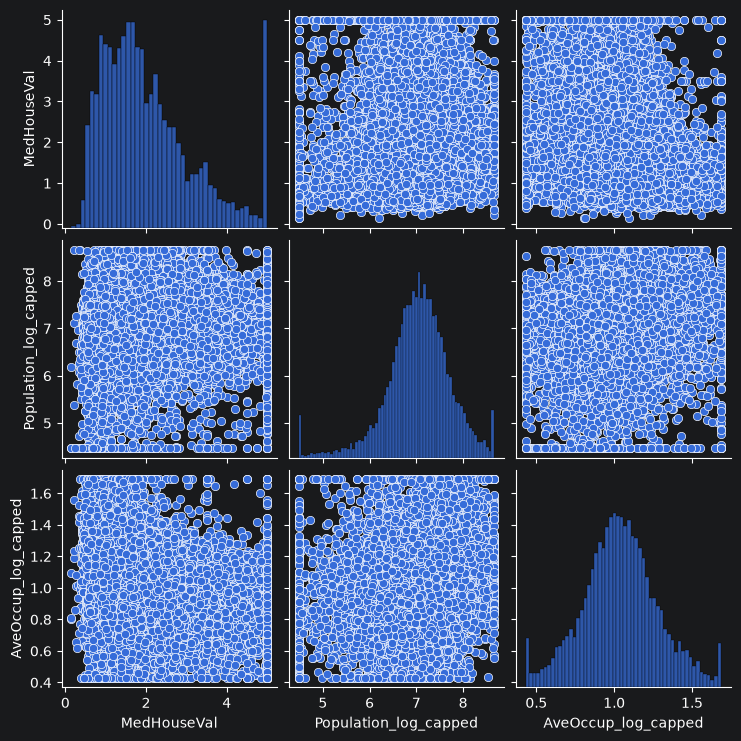

In [28]:
sns.pairplot(dane_do_heatmapy[['MedHouseVal','Population_log_capped','AveOccup_log_capped']])

Patrząc na to, że jest niska korrelacja oraz, że dane równolegle leżą na wykresach bez zależnosci od wielkości MedHouseVal, chciałem je usunąć. Ale czat sugeruję, że mogą być przydatne w modelu RandomForest, więc zostawię.

In [29]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [58]:
models = {
    'Linear Regression': linear_model.LinearRegression(),
    'Ridge Regression': linear_model.Ridge(alpha=1.0),
    'Lasso': linear_model.Lasso(alpha=0.01),
    'ElasticNet': linear_model.ElasticNet(alpha=0.01,l1_ratio=0.25),
    # 'LogisticRegrassion': linear_model.LogisticRegression(),
    'Random Forest': ensemble.RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': ensemble.GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_std, y_train)
    # Predykcja
    y_pred_train = model.predict(X_train_std)
    y_pred_test = model.predict(X_test_std)
    # Metryki
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    results[name] = {
    'y_pred': y_pred_test,
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'r2_train': r2_train
    }
    print(f"\n{name}:")
    print(f" R² (train): {r2_train:.4f}")
    print(f" R² (test): {r2:.4f}")
    print(f" RMSE: {rmse:.4f}")
    print(f" MAE: {mae:.4f}")



Linear Regression:
 R² (train): 0.6467
 R² (test): 0.6326
 RMSE: 0.6939
 MAE: 0.5220

Ridge Regression:
 R² (train): 0.6467
 R² (test): 0.6326
 RMSE: 0.6939
 MAE: 0.5220

Lasso:
 R² (train): 0.6435
 R² (test): 0.6302
 RMSE: 0.6961
 MAE: 0.5236

ElasticNet:
 R² (train): 0.6453
 R² (test): 0.6320
 RMSE: 0.6944
 MAE: 0.5227

Random Forest:
 R² (train): 0.9755
 R² (test): 0.8172
 RMSE: 0.4895
 MAE: 0.3123

Gradient Boosting:
 R² (train): 0.8117
 R² (test): 0.7845
 RMSE: 0.5315
 MAE: 0.3631


Regresje liniowe w podobny sposób zachowują się, a widać, że Random Forest nie jest stabilny -- R2 na train jest o wiele większy, niż na teście. W przyszłości spróbuję to naprawić

In [31]:
cv = KFold(n_splits=5,shuffle=True, random_state=42)
results_cv = {}

for name, model in models.items():
    pipe = Pipeline([('skaler',StandardScaler()),('model', model)])
    scores = cross_val_score(pipe, X,y, cv=cv, scoring='neg_mean_squared_error')
    results_cv[name] = scores
    print(f"\n{name}:")
    print(f" Scores per fold: {scores}")
    print(f" Mean: {scores.mean():.4f}")
    print(f" Std: {scores.std():.4f}")
    print(f" 95% CI: [{scores.mean() - 1.96*scores.std():.4f}, "
    f"{scores.mean() + 1.96*scores.std():.4f}]")


Linear Regression:
 Scores per fold: [-0.48147148 -0.47778022 -0.46131288 -0.44361426 -0.51042208]
 Mean: -0.4749
 Std: 0.0223
 95% CI: [-0.5185, -0.4313]

Ridge Regression:
 Scores per fold: [-0.48146544 -0.47778895 -0.46134128 -0.44360935 -0.51038871]
 Mean: -0.4749
 Std: 0.0222
 95% CI: [-0.5185, -0.4313]

Lasso:
 Scores per fold: [-0.48461105 -0.48198086 -0.46771685 -0.44756466 -0.51285502]
 Mean: -0.4789
 Std: 0.0215
 95% CI: [-0.5210, -0.4369]

ElasticNet:
 Scores per fold: [-0.48225165 -0.48026078 -0.4654018  -0.44500989 -0.51051391]
 Mean: -0.4767
 Std: 0.0215
 95% CI: [-0.5189, -0.4345]

Random Forest:
 Scores per fold: [-0.23853729 -0.23354732 -0.24254977 -0.21281773 -0.24186705]
 Mean: -0.2339
 Std: 0.0110
 95% CI: [-0.2554, -0.2123]


Teraz chcę popracować nad Hiperparametrami: alpha, l1_ratio regresji ridge/lasso, żeby znaleźć najlepsze wartości dla obu.

p.s. w sumie to wydaję się zbędne, skoro Random Forest jest o wiele lepszy, to lepiej dopracować go do stabilności, ale z chęcią przetestuję GridSearch

In [32]:
alphas = [0.001, 0.01, 0.1, 1, 10]

models = {'ridge': linear_model.Ridge(random_state=42),
          'lasso': linear_model.Lasso(random_state=42)
          }

najlepsze_alpha = {}

for nazwa,model in models.items():
    param_grid = {nazwa + '__alpha' : alphas}
    pipe_linear = make_pipeline(
        StandardScaler(),
         model
    )

    grid = GridSearchCV(pipe_linear, param_grid=param_grid, cv=cv, scoring='neg_mean_squared_error',n_jobs=-1)
    grid.fit(X,y)
    najlepsze_alpha[nazwa] = grid.best_params_[nazwa+'__alpha']
    # najlepsze_alpha.append({nazwa:grid.best_params_[nazwa+'__alpha']})
    print(f'Najlepsza alpha dla {nazwa}: {grid.best_params_[nazwa+'__alpha']}')

ridge_best_alpha = najlepsze_alpha['ridge']
lasso_best_alpha = najlepsze_alpha['lasso']


Najlepsza alpha dla ridge: 1
Najlepsza alpha dla lasso: 0.001


Mam najlepsze alpha dla Ridge/Alpha. Widać, że przy pierwszym treningu już trafiłem w najlepszy alpha dla Ridge, zostaje Lasso.

Wytrenuję model z powrotem i porównam wyniki.


In [33]:
model = linear_model.Lasso(alpha = lasso_best_alpha, random_state = 42)

pipe = Pipeline([('skaler',StandardScaler()),('model', model)])
scores = cross_val_score(pipe, X,y, cv=cv, scoring='neg_mean_squared_error')

results_cv['Lasso_tuned'] = scores

roznica_w_lasso = abs(results_cv['Lasso']-results_cv['Lasso_tuned'])
srednia_roznica = np.mean(roznica_w_lasso)


print(f'Różnica w score między dwoma Lasso: {roznica_w_lasso}')

print(f'Widać, że różnica między Lasso MSE a tuned Lasso MSE zlicza się w tysięcznych, a średnia różnica MSE to: {srednia_roznica:.3f}')

Różnica w score między dwoma Lasso: [0.00321842 0.00408211 0.00607989 0.00390844 0.00290629]
Widać, że różnica między Lasso MSE a tuned Lasso MSE zlicza się w tysięcznych, a średnia różnica MSE to: 0.004


Wracam do Random Foresta, który pokazał najlepsze wyniki. Spróbuję ustabilizować go, żeby można było z niego korzystać.

In [34]:
print(f'''Random forest:
R2 score dla train: {results['Random Forest']['r2_train']:.4f}
R2 score dla testu: {results['Random Forest']['r2']:.4f}
''')

print('Overfitting na train')

Random forest:
R2 score dla train: 0.9755
R2 score dla testu: 0.8172

Overfitting na train


Trzeba model ograniczyć, Spróbuję znaleźć najlepsze wartości dla max_depth oraz min samples leaf

In [41]:
param_grid = {'max_depth' : list(range(10,101,10)),
              'min_samples_leaf' : [1,5,10]
              }

model_random_forest = ensemble.RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

grid = GridSearchCV(model_random_forest, param_grid=param_grid, cv=5, n_jobs=-1, scoring ='neg_mean_squared_error')

grid.fit(X_train_std,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 5, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

In [47]:
model_random_forest_tuned = grid.best_estimator_

y_pred_train_rf_tuned = model_random_forest_tuned.predict(X_train_std)
y_pred_rf_tuned = model_random_forest_tuned.predict(X_test_std)

model_random_forest_tuned_r2_train = r2_score(y_train,y_pred_train_rf_tuned)
model_random_forest_tuned_r2 = r2_score(y_test,y_pred_rf_tuned)
print(f'Najlepsze parametry gridsearch: {grid.best_params_}')
print(f'RF train r2: {results['Random Forest']['r2_train']}, RF tuned train R2 {model_random_forest_tuned_r2_train}')
print(f'RF test r2: {results['Random Forest']['r2']} ,  RF tuned test R2 {model_random_forest_tuned_r2}')

Najlepsze parametry gridsearch: {'max_depth': 20, 'min_samples_leaf': 1}
RF train r2: 0.9755110498523866, RF tuned train R2 0.9744021940235444
RF test r2: 0.817175931370679 ,  RF tuned test R2 0.8173796488625932


Polepszył się r2 na teście po tuningu, ale i tak za mało. Spróbuję poszerzyć min_samples_leaf

In [51]:
param_grid = {'max_depth' : list(range(10,101,10)),
              'min_samples_leaf' : [1,5,10,20,30,50,100]
              }

model_random_forest = ensemble.RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

grid = GridSearchCV(model_random_forest, param_grid=param_grid, cv=5, n_jobs=-1, scoring ='neg_mean_squared_error', return_train_score=True)

grid.fit(X_train_std,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.

In [53]:
model_random_forest_tuned = grid.best_estimator_

y_pred_train_rf_tuned = model_random_forest_tuned.predict(X_train_std)
y_pred_rf_tuned = model_random_forest_tuned.predict(X_test_std)

model_random_forest_tuned_r2_train = r2_score(y_train,y_pred_train_rf_tuned)
model_random_forest_tuned_r2 = r2_score(y_test,y_pred_rf_tuned)
print(f'Najlepsze parametry gridsearch: {grid.best_params_}')
print(f'RF train r2: {results['Random Forest']['r2_train']}, RF tuned train R2 {model_random_forest_tuned_r2_train}')
print(f'RF test r2: {results['Random Forest']['r2']} ,  RF tuned test R2 {model_random_forest_tuned_r2}')

Najlepsze parametry gridsearch: {'max_depth': 20, 'min_samples_leaf': 1}
RF train r2: 0.9755110498523866, RF tuned train R2 0.9744021940235444
RF test r2: 0.817175931370679 ,  RF tuned test R2 0.8173796488625931


Ten sam wynik przy 2x czasie pracy treningu.

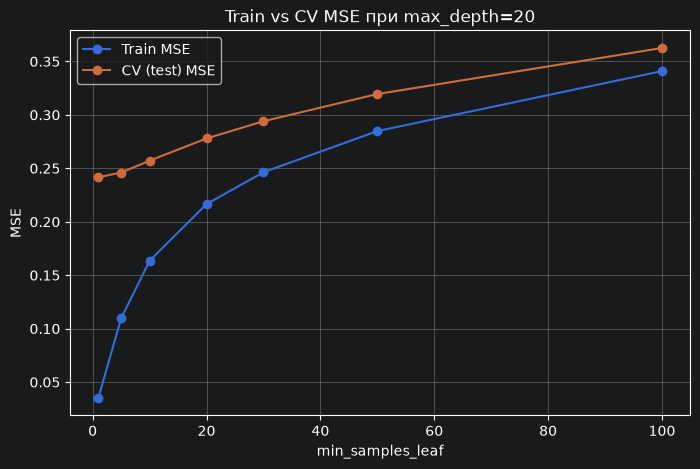

In [57]:
grid_pd = pd.DataFrame(grid.cv_results_)

best_max_depth = grid.best_params_['max_depth']
subset = grid_pd[grid_pd['param_max_depth'] == best_max_depth].sort_values('param_min_samples_leaf')

plt.figure(figsize=(8,5))
plt.plot(subset['param_min_samples_leaf'], -subset['mean_train_score'], marker='o', label='Train MSE')
plt.plot(subset['param_min_samples_leaf'], -subset['mean_test_score'], marker='o', label='CV (test) MSE')
plt.xlabel('min_samples_leaf')
plt.ylabel('MSE')
plt.title(f'Train vs CV MSE при max_depth={best_max_depth}')
plt.legend()
plt.grid(True)
plt.show()

Dzięki claude wygenerowałem ładny wykres, który pokazuje, że jednak MSE na teście i train ciągle rośnie z dodatkiem ograniczenia. Można zdecydować się np. na 5 listów, zbliży to wartości train-test, ale pogorszy test. Nie wiem co lepsze.

Z ciekawości chcę również wrócić do Gradient Boosting. Ma lekko gorsze wyniki, niż RF, ale stabilniejsze na train-test. Może uda się za pomocą Grid search poprawić wyniki tego modelu.

In [59]:
print(f'''Gradient Boosting:
R2 score dla train: {results['Gradient Boosting']['r2_train']:.4f}
R2 score dla testu: {results['Gradient Boosting']['r2']:.4f}
''')


Gradient Boosting:
R2 score dla train: 0.8117
R2 score dla testu: 0.7845



In [65]:
param_grid = {'learning_rate' : [0.01, 0.1, 1],
              'n_estimators' : [50,100,200],
              'max_depth' : [2,3,4,5],
              'min_samples_leaf' : [1,3,5,7,10]
              }

model_gradient_boosting = ensemble.GradientBoostingRegressor(random_state=42)

grid_gb = GridSearchCV(model_gradient_boosting, param_grid=param_grid, cv=5, n_jobs=-1, scoring ='neg_mean_squared_error', return_train_score=True)

grid_gb.fit(X_train_std,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be ava

In [66]:
model_gradient_boosting_tuned = grid_gb.best_estimator_

y_pred_train_gb_tuned = model_gradient_boosting_tuned.predict(X_train_std)
y_pred_gb_tuned = model_gradient_boosting_tuned.predict(X_test_std)

model_gradient_boosting_tuned_r2_train = r2_score(y_train,y_pred_train_gb_tuned)
model_gradient_boosting_tuned_r2 = r2_score(y_test,y_pred_gb_tuned)

print('Gradient Boosting:')
print(f'Najlepsze parametry gridsearch: {grid.best_params_}')
print(f'GB train r2: {results['Gradient Boosting']['r2_train']}, GB tuned train R2 {model_gradient_boosting_tuned_r2_train}')
print(f'GB test r2: {results['Gradient Boosting']['r2']} ,  GB tuned test R2 {model_gradient_boosting_tuned_r2}')

Gradient Boosting:
Najlepsze parametry gridsearch: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 200}
GB train r2: 0.8117154148146793, GB tuned train R2 0.9100961177101382
GB test r2: 0.7844531787644484 ,  GB tuned test R2 0.8387343578867136


GB jest lepszy i stabilniejszy od RF.

Również udało się polepszyć GB o 0.05 pp, co jest super.

Teraz chcę odpowiedzieć na 1 pytanie: czy cała praca miala sens, bo może bez przeróbki danych i dodawania feacherów modele by miały sens.

In [75]:
data2 = fetch_california_housing(as_frame=True)

dane2 = data2.frame

X2 = dane2.drop('MedHouseVal', axis=1)
y2 = dane2['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X2,y2, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

models2 = {
    'Linear Regression': linear_model.LinearRegression(),
    'Ridge Regression': linear_model.Ridge(alpha=1.0),
    'Lasso': linear_model.Lasso(alpha=0.01),
    'ElasticNet': linear_model.ElasticNet(alpha=0.01,l1_ratio=0.25),
    # 'LogisticRegrassion': linear_model.LogisticRegression(),
    'Random Forest': ensemble.RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': ensemble.GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results2 = {}

for name, model in models2.items():
    model.fit(X_train_std, y_train)
    # Predykcja
    y_pred_train = model.predict(X_train_std)
    y_pred_test = model.predict(X_test_std)
    # Metryki
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    results2[name] = {
    'y_pred': y_pred_test,
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'r2_train': r2_train
    }
    print(f"\n{name}:")
    print(f" R² (train): {r2_train:.4f}")
    print(f" R² (test): {r2:.4f}")
    print(f" RMSE: {rmse:.4f}")
    print(f" MAE: {mae:.4f}")




Linear Regression:
 R² (train): 0.6126
 R² (test): 0.5758
 RMSE: 0.7456
 MAE: 0.5332

Ridge Regression:
 R² (train): 0.6126
 R² (test): 0.5758
 RMSE: 0.7456
 MAE: 0.5332

Lasso:
 R² (train): 0.6085
 R² (test): 0.5816
 RMSE: 0.7404
 MAE: 0.5353

ElasticNet:
 R² (train): 0.6107
 R² (test): 0.5794
 RMSE: 0.7424
 MAE: 0.5336

Random Forest:
 R² (train): 0.9735
 R² (test): 0.8047
 RMSE: 0.5059
 MAE: 0.3278

Gradient Boosting:
 R² (train): 0.8049
 R² (test): 0.7756
 RMSE: 0.5422
 MAE: 0.3717


In [77]:
roznica_GB = model_gradient_boosting_tuned_r2 - results2['Gradient Boosting']['r2']
roznica_RF = model_random_forest_tuned_r2 - results2['Random Forest']['r2']

print('Porównanie Gradient Boosting:')

print(f'GB STANDARDOWY test r2: {results2['Random Forest']['r2']} ,  GB MÓJ tuned test R2 {model_gradient_boosting_tuned_r2}')
print(f'Uzysk mojego modelu: {roznica_GB}')


print('\nPorównanie Random Forestu:')

print(f'RF STANDARDOWY test r2: {results2['Random Forest']['r2']} ,  RF MÓJ tuned test R2 {model_random_forest_tuned_r2}')
print(f'Uzysk mojego modelu: {roznica_RF}')



Porównanie Gradient Boosting:
GB STANDARDOWY test r2: 0.8047061244071481 ,  GB MÓJ tuned test R2 0.8387343578867136
Uzysk modelu: 0.0630910414157052

Porównanie Random Forestu:
RF STANDARDOWY test r2: 0.8047061244071481 ,  RF MÓJ tuned test R2 0.8173796488625931
Uzysk modelu: 0.012673524455445007


Uzyskałem 6.3% na GB oraz 1.27% na RF:)
A gdybym miał takie same parametry jak i best_estimators?

In [78]:
data2 = fetch_california_housing(as_frame=True)

dane2 = data2.frame

X2 = dane2.drop('MedHouseVal', axis=1)
y2 = dane2['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X2,y2, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

models3 = {

    'Random Forest': ensemble.RandomForestRegressor(n_estimators=100, max_depth = 20, min_samples_leaf = 1, random_state=42, n_jobs=-1),
    'Gradient Boosting': ensemble.GradientBoostingRegressor(learning_rate = 0.1, max_depth = 5, min_samples_leaf = 3, n_estimators = 200, random_state=42)
}

results3 = {}

for name, model in models3.items():
    model.fit(X_train_std, y_train)
    # Predykcja
    y_pred_train = model.predict(X_train_std)
    y_pred_test = model.predict(X_test_std)
    # Metryki
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    results3[name] = {
    'y_pred': y_pred_test,
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'r2_train': r2_train
    }
    print(f"\n{name}:")
    print(f" R² (train): {r2_train:.4f}")
    print(f" R² (test): {r2:.4f}")
    print(f" RMSE: {rmse:.4f}")
    print(f" MAE: {mae:.4f}")




Random Forest:
 R² (train): 0.9721
 R² (test): 0.8045
 RMSE: 0.5061
 MAE: 0.3280

Gradient Boosting:
 R² (train): 0.9018
 R² (test): 0.8304
 RMSE: 0.4714
 MAE: 0.3118


In [80]:
roznica_GB_2 = model_gradient_boosting_tuned_r2 - results3['Gradient Boosting']['r2']
roznica_RF_2 = model_random_forest_tuned_r2 - results3['Random Forest']['r2']

print('Porównanie Gradient Boosting:')

print(f'GB STANDARDOWY + PARAMETRY test r2: {results3['Random Forest']['r2']} ,  GB MÓJ tuned test R2 {model_gradient_boosting_tuned_r2}')
print(f'Uzysk mojego modelu: {roznica_GB_2}')


print('\nPorównanie Random Forestu:')

print(f'RF STANDARDOWY test r2: {results3['Random Forest']['r2']} ,  RF MÓJ tuned test R2 {model_random_forest_tuned_r2}')
print(f'Uzysk mojego modelu: {roznica_RF_2}')

Porównanie Gradient Boosting:
GB STANDARDOWY + PARAMETRY test r2: 0.8045129499098251 ,  GB MÓJ tuned test R2 0.8387343578867136
Uzysk mojego modelu: 0.0083323830838129

Porównanie Random Forestu:
RF STANDARDOWY test r2: 0.8045129499098251 ,  RF MÓJ tuned test R2 0.8173796488625931
Uzysk mojego modelu: 0.01286669895276793


Wniosek:

Najlepszy model: Gradient Boosting, bo jest najbardziej stabilny i dał najlepsze wyniki: wyjaśnia 83% wszystkich wszystkich przypadków, odchylających się od średniej

Drugi najlepszy model: Random Forest: jest mniej stabilny, bo jest większa różnica między r2 train/test oraz ma niższy wskaźnik r2 -- 81.74%

mój feature engineering dał jakieś owoce, ale ogólnie samo dopieszczanie parametrów przyniosło najwięcej.

Wynik finalny porównania:

Mój feature engineering na GB przyniosł 0.8% utargu
A na RF -- 1,29% utargu